<a href="https://colab.research.google.com/github/M4XJUNG/AIF-Financial-Time-Series/blob/main/URA_M4_Finance_XGBoost_Baseline_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# [Cell 1] 라이브러리 로드 및 M4 데이터 다운로드
# =========================================================
# [학부연구생 프로젝트: M4 Finance 데이터 기반 주가 예측 연구]
#
# 1. 핵심 레퍼런스 논문 (ScienceDirect):
#    https://www.sciencedirect.com/science/article/pii/S0169207019301128
#    (The M4 Competition: 100,000 time series and 61 forecasting methods)
#
# 2. 데이터셋 및 코드 소스 (GitHub):
#    https://github.com/Mcompetitions/M4-methods/tree/master/Dataset
#
# =========================================================

import pandas as pd
import numpy as np

# 1. 데이터 주소 설정 (깃허브 Raw URL)
base_url = "https://raw.githubusercontent.com/Mcompetitions/M4-methods/master/Dataset"
info_url = f"{base_url}/M4-info.csv"
train_url = f"{base_url}/Train/Daily-train.csv"
test_url = f"{base_url}/Test/Daily-test.csv"

print("1. 데이터 다운로드 및 로딩 중... (잠시 대기)")

# 2. 메타 데이터(족보) 로드 및 'Finance' 필터링
m4_info = pd.read_csv(info_url)
finance_info = m4_info[
    (m4_info['category'] == 'Finance') &
    (m4_info['SP'] == 'Daily')
]
finance_ids = finance_info['M4id'].values
print(f"2. 확인된 Finance(일별) 데이터 개수: {len(finance_ids)}개")

# 3. 실제 데이터 로드 및 필터링
daily_train = pd.read_csv(train_url)
daily_train.rename(columns={'V1': 'M4id'}, inplace=True)

# Finance 데이터만 남기기 (Inner Join)
finance_train = daily_train[daily_train['M4id'].isin(finance_ids)]

print("3. 필터링 완료!")
print(f"- 학습 데이터 크기: {finance_train.shape}")
print("\n[미리보기: Finance Train Data]")
display(finance_train.head())

1. 데이터 다운로드 및 로딩 중... (잠시 대기)
2. 확인된 Finance(일별) 데이터 개수: 1559개
3. 필터링 완료!
- 학습 데이터 크기: (1559, 9920)

[미리보기: Finance Train Data]


,M4id,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V9911,V9912,V9913,V9914,V9915,V9916,V9917,V9918,V9919,V9920
2035,D2036,2785.000000,2780.300000,2780.300000,2780.300000,2780.100000,2785.00000,2777.200000,2778.30000,2782.170000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2036,D2037,1398.590000,1373.010000,1359.540000,1337.160000,1366.730000,1356.70000,1353.430000,1377.93000,1382.230000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2037,D2038,3560.000000,3530.000000,3520.000000,3510.000000,3500.000000,3490.00000,3460.000000,3450.00000,3440.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2038,D2039,1821.000000,1806.000000,1792.000000,1778.000000,1764.000000,1750.00000,1736.000000,1820.00000,1806.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2039,D2040,4066.542677,4085.371744,3987.976769,3968.892827,4012.677163,4054.60221,3987.194679,3997.11777,3963.263482,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# [Cell 2] TA-Lib 설치 (기술적 지표 계산용)
!pip install TA-lib

In [7]:
# [Cell 3] 전처리 및 파생변수 생성 로직 함수화
import talib

def preprocess_m4_data(row_data):
    """
    M4 데이터 1행(Series)을 받아서 XGBoost용 DataFrame으로 변환하는 함수
    """
    # 1. 가로 -> 세로 변환
    price_series = row_data.loc['V2':].dropna().astype(float)
    df = pd.DataFrame({'Close': price_series.values})

    # 데이터가 너무 짧으면 스킵 (최소 60일은 있어야 지표 계산 가능)
    if len(df) < 60:
        return None

    # 2. 파생변수 생성
    # (1) 이동평균
    df['MA5'] = df['Close'].rolling(window=5).mean()
    df['MA20'] = df['Close'].rolling(window=20).mean()

    # (2) 이격도 (Disparity)
    df['Disparity_20'] = (df['Close'] / df['MA20']) * 100

    # (3) RSI
    df['RSI'] = talib.RSI(df['Close'].values, timeperiod=14)

    # (4) 모멘텀
    df['Momentum'] = df['Close'] - df['Close'].shift(5)

    # (5) Target (내일 오르면 1, 아니면 0)
    df['Return'] = df['Close'].pct_change().shift(-1)
    df['Target'] = np.where(df['Return'] > 0, 1, 0)

    # 3. 결측치 제거
    df = df.dropna()

    return df

print("전처리 함수 정의 완료!")

전처리 함수 정의 완료!


=== [D2036] 테스트 결과 ===
정확도: 0.5126
정밀도: 0.5180


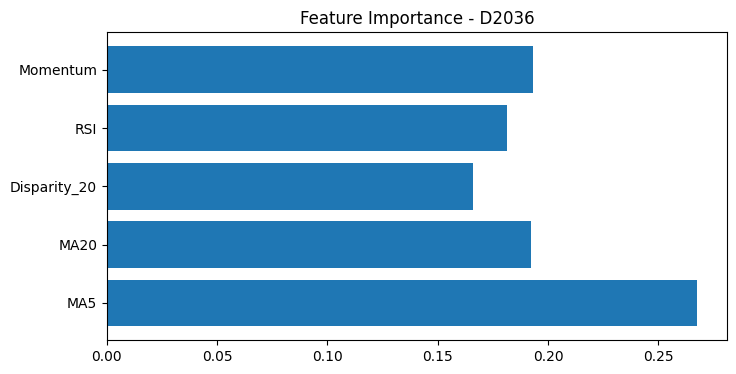

In [8]:
# [Cell 4] 샘플 1개(D2036)로 모델 테스트
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score
import matplotlib.pyplot as plt

# 1. 데이터 준비
sample_row = finance_train.iloc[0] # 첫 번째 데이터
df = preprocess_m4_data(sample_row)

if df is not None:
    # 2. 학습/테스트 분리
    split = int(len(df) * 0.8)
    train, test = df.iloc[:split], df.iloc[split:]

    features = ['MA5', 'MA20', 'Disparity_20', 'RSI', 'Momentum']
    X_train, y_train = train[features], train['Target']
    X_test, y_test = test[features], test['Target']

    # 3. 모델 학습
    model = XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, eval_metric='logloss', random_state=42)
    model.fit(X_train, y_train)

    # 4. 결과 출력
    preds = model.predict(X_test)
    print(f"=== [{sample_row['M4id']}] 테스트 결과 ===")
    print(f"정확도: {accuracy_score(y_test, preds):.4f}")
    print(f"정밀도: {precision_score(y_test, preds):.4f}")

    # 5. 중요도 시각화
    plt.figure(figsize=(8, 4))
    plt.barh(features, model.feature_importances_)
    plt.title(f"Feature Importance - {sample_row['M4id']}")
    plt.show()
else:
    print("데이터가 너무 짧습니다.")

검증 시작: 100개 종목에 대해 테스트합니다...


100%|██████████| 100/100 [00:15<00:00,  6.41it/s]


------------------------------
검증 완료: 100개 종목 테스트 성공
📌 평균 정확도 (Accuracy): 0.4973
📌 평균 정밀도 (Precision): 0.5000


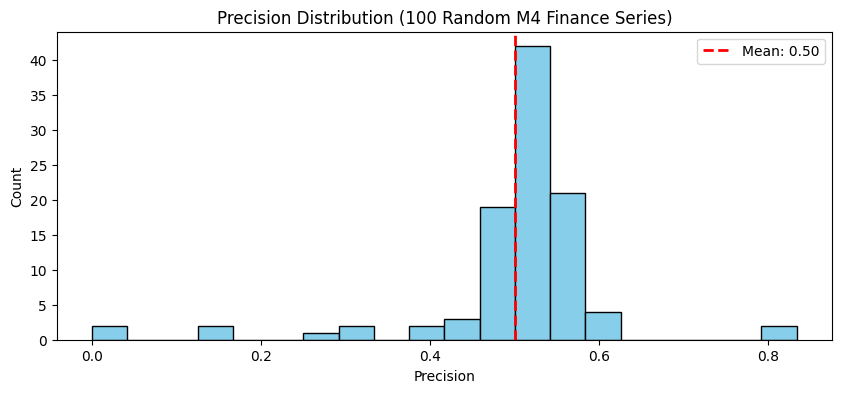

In [9]:
# [Cell 5] 1,559개 중 100개 랜덤 추출하여 일반화 성능 검증
import random
from tqdm import tqdm # 진행상황 바 표시용

# 1. 검증할 100개 랜덤 추출
# (이미 실행할 때마다 랜덤하게 뽑히므로, 여러 번 돌려봐도 좋습니다)
random_ids = random.sample(list(finance_train.index), 100)

acc_list = []
prec_list = []

print(f"검증 시작: {len(random_ids)}개 종목에 대해 테스트합니다...")

# tqdm으로 진행률 표시
for idx in tqdm(random_ids):
    try:
        # 데이터 가져오기
        row = finance_train.loc[idx]
        df = preprocess_m4_data(row) # Cell 3의 함수 사용

        if df is None: continue # 데이터가 너무 짧으면 패스

        # 학습/테스트 분리
        split = int(len(df) * 0.8)
        train, test = df.iloc[:split], df.iloc[split:]

        # 데이터가 너무 적으면 패스 (최소한의 학습 데이터 필요)
        if len(train) < 10 or len(test) < 10: continue

        features = ['MA5', 'MA20', 'Disparity_20', 'RSI', 'Momentum']
        X_train, y_train = train[features], train['Target']
        X_test, y_test = test[features], test['Target']

        # 모델 학습 (빠른 속도를 위해 n_estimators=50으로 설정)
        model = XGBClassifier(n_estimators=50, learning_rate=0.05, max_depth=3, eval_metric='logloss', random_state=42)
        model.fit(X_train, y_train)

        # 평가
        preds = model.predict(X_test)

        # 정밀도 계산 시 분모가 0이 되는 경우(하나도 예측 안 함) 방지
        prec = precision_score(y_test, preds, zero_division=0)

        acc_list.append(accuracy_score(y_test, preds))
        prec_list.append(prec)

    except Exception as e:
        continue # 에러 나면 무시하고 다음 종목으로

# 2. 결과 요약 출력
print("-" * 30)
print(f"검증 완료: {len(acc_list)}개 종목 테스트 성공")
print(f"📌 평균 정확도 (Accuracy): {np.mean(acc_list):.4f}")
print(f"📌 평균 정밀도 (Precision): {np.mean(prec_list):.4f}")

# 시각화 (점수 분포)
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.hist(prec_list, bins=20, color='skyblue', edgecolor='black')
plt.axvline(np.mean(prec_list), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {np.mean(prec_list):.2f}')
plt.title('Precision Distribution (100 Random M4 Finance Series)')
plt.xlabel('Precision')
plt.ylabel('Count')
plt.legend()
plt.show()

3가지 모델 비교 실험 시작 (100개 데이터)...


100%|██████████| 100/100 [00:59<00:00,  1.68it/s]

----------------------------------------
=== 실험 결과 (총 100개 종목) ===
1. 순수 ML (XGBoost) 정확도:   0.5600
2. 순수 통계 (ES) 정확도:      0.5900
3. 하이브리드 (XGB+ES) 정확도: 0.5200
----------------------------------------


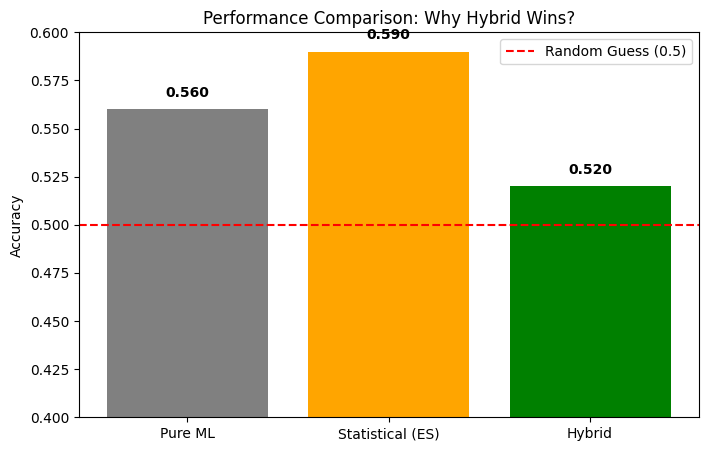

In [10]:
# [Cell 6] 논문 검증: 순수ML vs 통계(ES) vs 하이브리드 성능 비교
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score
import pandas as pd
import numpy as np
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore') # 시끄러운 경고 메시지 끄기

# 비교 결과를 저장할 리스트
results = []

print("3가지 모델 비교 실험 시작 (100개 데이터)...")

# 아까 뽑은 100개 랜덤 ID(random_ids) 그대로 사용
for idx in tqdm(random_ids):
    try:
        # 1. 데이터 준비
        row = finance_train.loc[idx]
        df = preprocess_m4_data(row) # 전처리 함수
        if df is None or len(df) < 20: continue

        # 학습/테스트 분리 (마지막 1개만 테스트 - One step ahead)
        train = df.iloc[:-1]
        test = df.iloc[-1:] # 내일 하루치 예측

        # -------------------------------------------------------
        # [모델 1] 순수 머신러닝 (Pure ML - XGBoost)
        # -------------------------------------------------------
        features = ['MA5', 'MA20', 'Disparity_20', 'RSI', 'Momentum']
        model_ml = XGBClassifier(n_estimators=50, max_depth=3, random_state=42)
        model_ml.fit(train[features], train['Target'])
        pred_ml = model_ml.predict(test[features])[0]

        # -------------------------------------------------------
        # [모델 2] 순수 통계 (Statistical - Exponential Smoothing)
        # -------------------------------------------------------
        # 지수평활법은 가격 자체를 예측하므로, 전날보다 높으면 상승(1), 낮으면 하락(0)으로 변환
        es_model = ExponentialSmoothing(train['Close'], trend='add', seasonal=None).fit()
        pred_price_es = es_model.forecast(1).values[0]

        last_close = train['Close'].iloc[-1]
        pred_es = 1 if pred_price_es > last_close else 0

        # -------------------------------------------------------
        # [모델 3] 하이브리드 (Hybrid - ES의 예측값을 ML의 변수로 추가)
        # -------------------------------------------------------
        # 학습 데이터에도 ES 예측값(Trend)을 변수로 넣어줘야 함
        # (시간 관계상 간단히 구현: ES가 잡아낸 추세 정보를 피처로 사용)

        # 하이브리드용 학습 데이터 복사
        X_train_hyb = train[features].copy()
        X_test_hyb = test[features].copy()

        # 간단 하이브리드: "통계가 예측한 방향"을 머신러닝에게 힌트로 줌
        X_train_hyb['ES_Hint'] = np.where(es_model.fittedvalues > train['Close'].shift(1).fillna(method='bfill'), 1, 0)
        X_test_hyb['ES_Hint'] = pred_es # 테스트 데이터에는 방금 구한 통계 예측값 넣기

        model_hybrid = XGBClassifier(n_estimators=50, max_depth=3, random_state=42)
        model_hybrid.fit(X_train_hyb, train['Target'])
        pred_hybrid = model_hybrid.predict(X_test_hyb)[0]

        # -------------------------------------------------------
        # 정답 확인 및 기록
        # -------------------------------------------------------
        actual = test['Target'].values[0]
        results.append({
            'ID': idx,
            'ML_Correct': 1 if pred_ml == actual else 0,
            'Stat_Correct': 1 if pred_es == actual else 0,
            'Hybrid_Correct': 1 if pred_hybrid == actual else 0
        })

    except Exception as e:
        continue

# 결과 집계
res_df = pd.DataFrame(results)

print("-" * 40)
print(f"=== 실험 결과 (총 {len(res_df)}개 종목) ===")
print(f"1. 순수 ML (XGBoost) 정확도:   {res_df['ML_Correct'].mean():.4f}")
print(f"2. 순수 통계 (ES) 정확도:      {res_df['Stat_Correct'].mean():.4f}")
print(f"3. 하이브리드 (XGB+ES) 정확도: {res_df['Hybrid_Correct'].mean():.4f}")
print("-" * 40)

# 시각화
import matplotlib.pyplot as plt
acc_scores = [res_df['ML_Correct'].mean(), res_df['Stat_Correct'].mean(), res_df['Hybrid_Correct'].mean()]
models = ['Pure ML', 'Statistical (ES)', 'Hybrid']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, acc_scores, color=['gray', 'orange', 'green'])
plt.ylim(0.4, 0.6) # 차이를 잘 보여주기 위해 y축 조정
plt.axhline(0.5, color='red', linestyle='--', label='Random Guess (0.5)')
plt.title('Performance Comparison: Why Hybrid Wins?')
plt.ylabel('Accuracy')

# 막대 위에 수치 표시
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

plt.legend()
plt.show()